In [4]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# to call data augmentation technique
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential ,load_model , Model
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix , classification_report

In [5]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False

In [6]:
## to do data augmentation: 
img_gen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rotation_range=20
)

In [7]:
#  Define Class Labels
class_labels = {'tumor': 0, 'no_tumor': 1}  

In [1]:
 import os
 import shutil
 import random

 # Define your paths
 source_dir = 'Data'
 train_dir = 'Train'
 val_dir = 'Validation'
 test_dir = 'Test'

 # Create directories if they do not exist
 os.makedirs(train_dir, exist_ok=True)
 os.makedirs(val_dir, exist_ok=True)
 os.makedirs(test_dir, exist_ok=True)

 # Get list of all files
 all_files = []
 for root, dirs, files in os.walk(source_dir):
     for file in files:
         if file.endswith(('.png', '.jpg', '.jpeg')):  # Add more image extensions if needed
             all_files.append(os.path.join(root, file))

 # Shuffle the list of files
 random.shuffle(all_files)

 # Split the files
 total_files = len(all_files)
 train_split = int(0.8 * total_files)
 test_split = int(0.2 * train_split)

 train_files = all_files[:train_split]
 val_files = all_files[train_split:train_split + test_split]
 test_files = all_files[train_split + test_split:]

 # Function to move files
 def move_files(file_list, target_dir):
     for file in file_list:
         class_name = os.path.basename(os.path.dirname(file))
         target_class_dir = os.path.join(target_dir, class_name)
         os.makedirs(target_class_dir, exist_ok=True)
         shutil.move(file, os.path.join(target_class_dir, os.path.basename(file)))

 # Move files to respective directories
 move_files(train_files, train_dir)
 move_files(val_files, val_dir)
 move_files(test_files, test_dir)

 print("Files have been moved successfully.")


Files have been moved successfully.


In [8]:
#                                Prepare the data
#                                Reading from the folder directly 
# shufle the data means يخلط الداتا 
# batch size means how many parts will the data be splitted two for one epoch
# epoch is the one time the fit generation take the from data 

train_gen = img_gen.flow_from_directory( "Train/",
                                        target_size = (256, 256) ,
                                        class_mode = 'binary' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =1) # 32

valid_gen = img_gen.flow_from_directory( "Validation/",
                                        target_size = (256, 256) ,
                                        class_mode = 'binary' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =1)
test_gen = img_gen.flow_from_directory( "Test/",
                                        target_size = (256, 256) ,
                                        class_mode = 'binary' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =1)

Found 306 images belonging to 2 classes.
Found 61 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [9]:
img_shape = (256,256)

In [10]:
# model.trainable = False
# for layer in base_model.layers[:-2]:
#     layer.trainable = False
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),# rectified linear unit 
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 flatten (Flatten)           (None, 131072)            0         
                                                                 
 dense (Dense)               (None, 256)               33554688  
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                       

In [12]:
-early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('BrainTumor_Classification_256px.h5', save_best_only=True, monitor='val_loss',verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.000001,verbose=1)


# Train the top layers
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    validation_data=valid_gen,
    epochs=100,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/100


94/94 [==============================] - ETA: 0s - loss: 0.6301 - accuracy: 0.7115
Epoch 1: val_loss improved from inf to 10.24196, saving model to BrainTumor_Classification_256px.h5


d:\anaconda\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


94/94 [==============================] - 303s 3s/step - loss: 0.6301 - accuracy: 0.7115 - val_loss: 10.2420 - val_accuracy: 0.5592 - lr: 0.0010
Epoch 2/100
94/94 [==============================] - ETA: 0s - loss: 0.5512 - accuracy: 0.7597
Epoch 2: val_loss improved from 10.24196 to 1.90958, saving model to BrainTumor_Classification_256px.h5
94/94 [==============================] - 214s 2s/step - loss: 0.5512 - accuracy: 0.7597 - val_loss: 1.9096 - val_accuracy: 0.5592 - lr: 0.0010
Epoch 3/100
94/94 [==============================] - ETA: 0s - loss: 0.5167 - accuracy: 0.7677
Epoch 3: val_loss did not improve from 1.90958
94/94 [==============================] - 208s 2s/step - loss: 0.5167 - accuracy: 0.7677 - val_loss: 2.1689 - val_accuracy: 0.5592 - lr: 0.0010
Epoch 4/100
94/94 [==============================] - ETA: 0s - loss: 0.4966 - accuracy: 0.7728
Epoch 4: val_loss improved from 1.90958 to 0.43081, saving model to BrainTumor_Classification_256px.h5
94/94 [========================

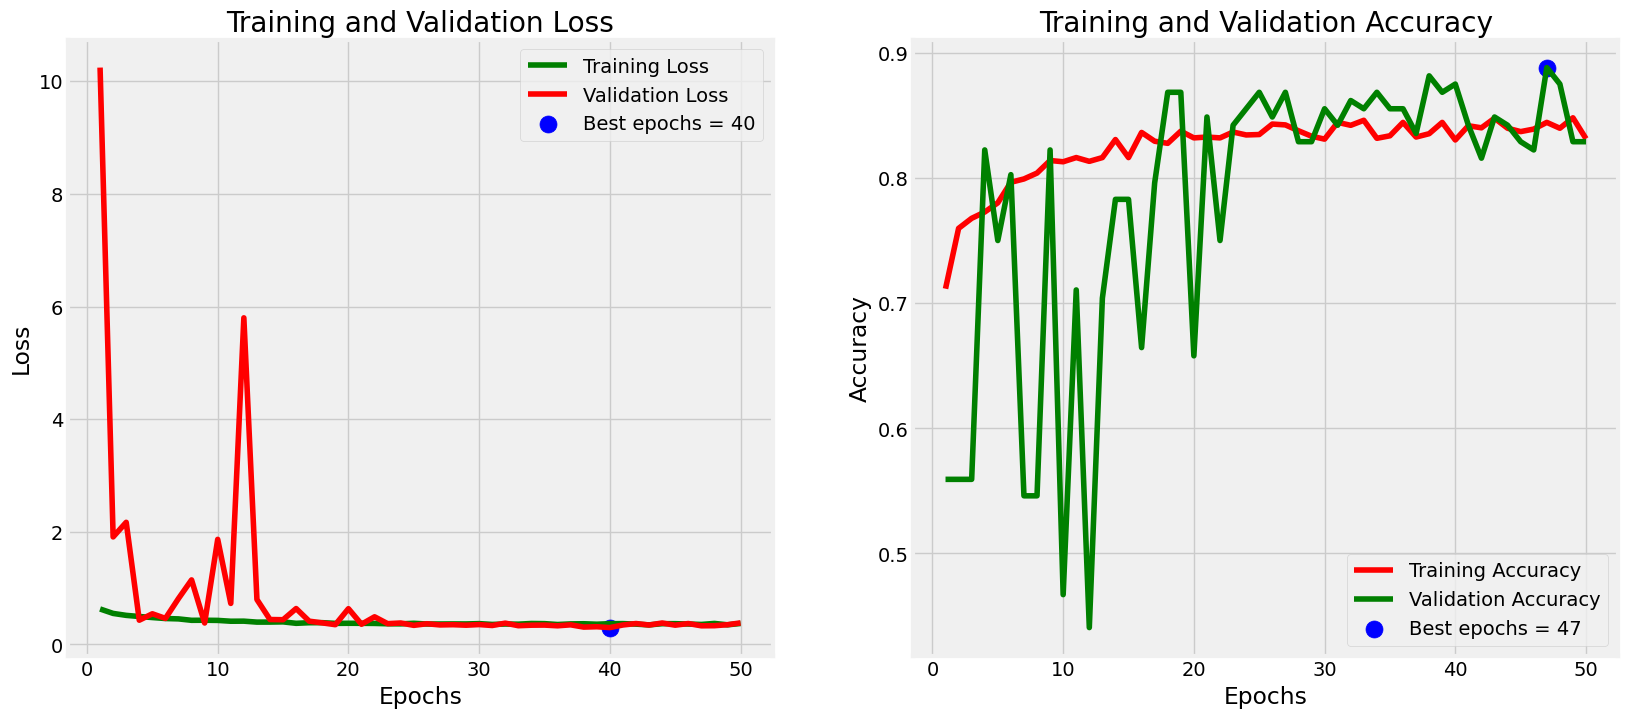

In [13]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'g' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'r' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [23]:
train_score = model.evaluate(train_gen , steps =len(train_gen) , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = len(valid_gen) , verbose = 1)
test_score = model.evaluate(test_gen , steps = len(test_gen) , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

604/604 [==============================] - 61s 100ms/step - loss: 0.3353 - accuracy: 0.8444
Train Loss:  0.3280525207519531
Train Accuracy:  0.8513244986534119
--------------------
Validation Loss:  0.35781311988830566
Validation Accuracy:  0.8486841917037964
--------------------
Test Loss:  0.33525699377059937
Test Accuracy:  0.8443708419799805


In [26]:
y_pred_prob = model.predict(test_gen, steps=len(test_gen))
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary class labels


604/604 [==============================] - 62s 102ms/step


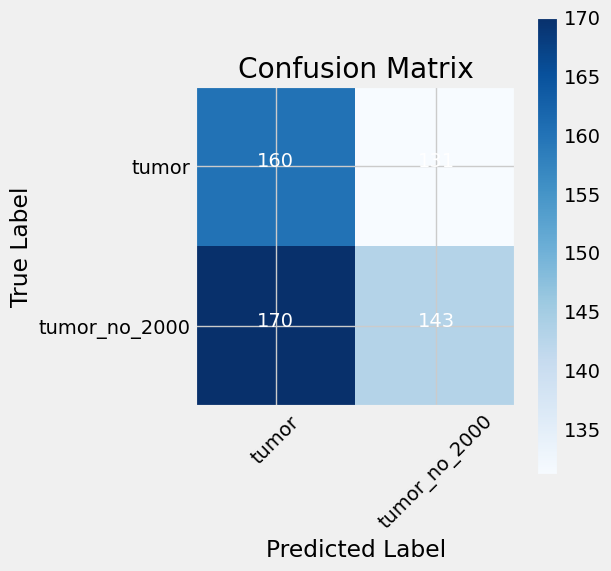

In [27]:
# Get class indices and class names
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
train_gen.class_indices

In [ ]:
from tensorflow.keras.models import load_model

# Load the best model
model = load_model('BrainTumor_Classification_256px.h5')


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Function to preprocess the image
def preprocess_image(image_path, target_size=(256, 256)):
    img = load_img(image_path, target_size=target_size)  # Load the image
    img_array = img_to_array(img)  # Convert the image to array
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to match the model's input shape
    img_array = img_array / 255.0  # Rescale the image
    return img_array

# Example image path
image_path = "Test\\tumor\\29.jpg"
preprocessed_image = preprocess_image(image_path)


# Predict the class of the image
prediction = model.predict(preprocessed_image)
predicted_class = (prediction > 0.5).astype(int)  # Binary classification


In [ ]:
predicted_class[0][0]